## Module 2: Regression homework zoomcamp

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df =pd.read_csv('/Users/foroghakbari/Zoomcamp/ml_course/zoomcamp_ml/regression/car_fuel_efficiency_2026.csv')

In [3]:
df.head(4)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5


## Preparing the dataset
Use only the following columns:

'engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg'
EDA
Look at the fuel_efficiency_mpg variable. Does it have a long tail?


In [4]:
df =df[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']]

In [5]:
df.count()

engine_displacement    10000
horsepower              9123
vehicle_weight         10000
model_year             10000
fuel_efficiency_mpg    10000
dtype: int64

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Skewness: 0.081


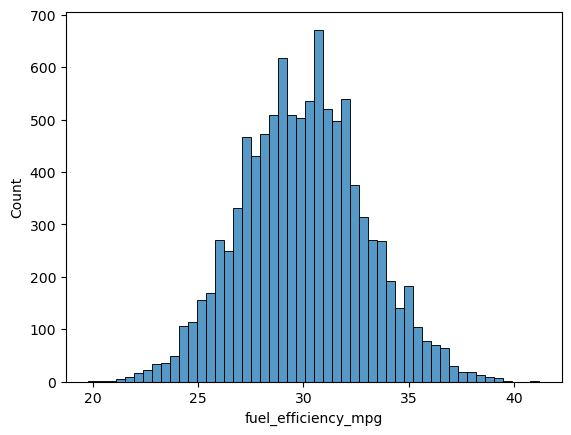

In [6]:
sns.histplot(df.fuel_efficiency_mpg, bins=50) #no long tail 
#check symmetry 
print(f"Skewness: {df['fuel_efficiency_mpg'].skew():.3f}")
 #looks relatively normally distributed

## Question 1- There's one column with missing values. What is it?

horsepower

In [7]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

In [8]:
df.count() #horsepower has missing

engine_displacement    10000
horsepower              9123
vehicle_weight         10000
model_year             10000
fuel_efficiency_mpg    10000
dtype: int64

In [9]:
df['horsepower'].isnull().sum()

877

## Question 2- What's the median (50% percentile) for variable 'horsepower'?

In [10]:
df['horsepower'].median() #what is the median valye

254.0

### Question 3 
* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good


In [11]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

# check count
print(f"Total records: {n}")
print(f"Training set: {len(df_train)} records ({len(df_train)/n*100:.1f}%)")
print(f"Validation set: {len(df_val)} records ({len(df_val)/n*100:.1f}%)")
print(f"Test set: {len(df_test)} records ({len(df_test)/n*100:.1f}%)")

Total records: 10000
Training set: 6000 records (60.0%)
Validation set: 2000 records (20.0%)
Test set: 2000 records (20.0%)


In [12]:
# define functions here 
import numpy as np

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


# Function to predict
def predict(X, w0, w):
    return w0 + X.dot(w)


# Function to calculate RMSE
def rmse(y_true, y_pred):
    se = (y_true - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [13]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


def run_experiment(df_train, df_val, base, target, column='horsepower',
                   strategy='zero', plot=True):
    """
    Fill NaNs in `column` using the given strategy, train a linear
    regression model, and return the validation RMSE.

    strategy: 'zero' or 'mean'
    plot: if True, show y_pred vs y_train histograms
    """
    # Work on copies so the originals stay untouched
    df_train_filled = df_train.copy()
    df_val_filled = df_val.copy()

    # Choose the fill value
    if strategy == 'zero':
        fill_value = 0
    elif strategy == 'mean':
        fill_value = df_train[column].mean()  # from training data only
    else:
        raise ValueError("strategy must be 'zero' or 'mean'")

    df_train_filled[column] = df_train_filled[column].fillna(fill_value)
    df_val_filled[column] = df_val_filled[column].fillna(fill_value)

    # Prepare data
    X_train = df_train_filled[base].values
    y_train = df_train_filled[target].values
    X_val = df_val_filled[base].values
    y_val = df_val_filled[target].values

    # Train model
    w0, w = train_linear_regression(X_train, y_train)

    # Predict and score
    y_pred = predict(X_val, w0, w)
    score = round(rmse(y_val, y_pred), 2)

    # Plot
    if plot:
        plt.figure(figsize=(7, 4))
        sns.histplot(y_train, color='blue', alpha=0.5, bins=50, label='y_train')
        sns.histplot(y_pred, color='red', alpha=0.5, bins=50, label='y_pred')
        plt.title(f"Fill with {strategy} (RMSE = {score})")
        plt.xlabel(target)
        plt.legend()
        plt.show()

    return score

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


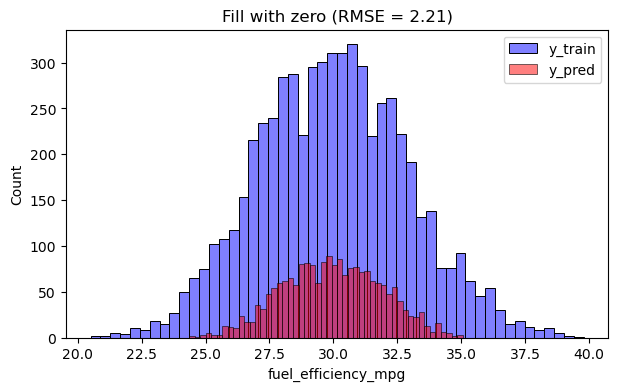

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


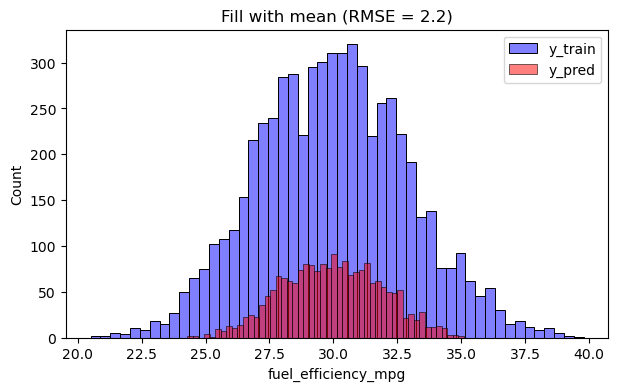

RMSE with 0:    2.21
RMSE with mean: 2.2
Difference:     0.01
Comment: Filling with the mean gives a lower RMSE, so it is the better strategy.


In [15]:
rmse_zero = run_experiment(df_train, df_val, base, target, strategy='zero')
rmse_mean = run_experiment(df_train, df_val, base, target, strategy='mean')

print(f"RMSE with 0:    {rmse_zero}")
print(f"RMSE with mean: {rmse_mean}")
print(f"Difference:     {abs(rmse_zero - rmse_mean):.2f}")

if rmse_mean < rmse_zero:
    print("Comment: Filling with the mean gives a lower RMSE, so it is the better strategy.")
elif rmse_zero < rmse_mean:
    print("Comment: Filling with 0 gives a lower RMSE, so it is the better strategy.")
else:
    print("Comment: Both strategies give the same RMSE.")

## Q4. 
* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

In [16]:
df_train_reg = df_train.copy()
df_val_reg = df_val.copy()

# fill nAs with 0s
df_train_reg['horsepower'] = df_train_reg['horsepower'].fillna(0)
df_val_reg['horsepower'] = df_val_reg['horsepower'].fillna(0)


X_train_reg = df_train_reg[base].values
y_train_reg = df_train_reg[target].values
X_val_reg = df_val_reg[base].values
y_val_reg = df_val_reg[target].values

In [17]:
# Function to train regularized linear regression
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    # Add regularization term
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg
    
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]


In [18]:
# Test different values of r
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_scores = {}

#loop 
for r in r_values:
    w0_reg, w_reg = train_linear_regression_reg(X_train_reg, y_train_reg, r=r)
    
    # Make predictions
    y_pred_reg = predict(X_val_reg, w0_reg, w_reg)
    
    # Calculate RMSE
    rmse_score = round(rmse(y_val_reg, y_pred_reg), 2)
    rmse_scores[r] = rmse_score
    
    print(f"r = {r:6.2f} -> RMSE = {rmse_score:.2f}")



best_rmse = min(rmse_scores.values())
best_r_values = [r for r, score in rmse_scores.items() if score == best_rmse]
best_r = min(best_r_values)  # If multiple have same RMSE, select smallest r

print(f"Best RMSE: {best_rmse:.2f}")
print(f"Best r: {best_r}")

if len(best_r_values) > 1:
    print(f"\nNote: r values {best_r_values} all achieved RMSE = {best_rmse:.2f}")
    print(f"Selected r = {best_r} (smallest r among tied values)")

r =   0.00 -> RMSE = 2.21
r =   0.01 -> RMSE = 2.21
r =   0.10 -> RMSE = 2.22
r =   1.00 -> RMSE = 2.35
r =   5.00 -> RMSE = 2.41
r =  10.00 -> RMSE = 2.42
r = 100.00 -> RMSE = 2.43
Best RMSE: 2.21
Best r: 0

Note: r values [0, 0.01] all achieved RMSE = 2.21
Selected r = 0 (smallest r among tied values)


### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)


In [19]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores_per_seed = []


In [20]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test



In [21]:
for seed in seeds:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train_seed = df.iloc[idx[:n_train]]
    df_val_seed = df.iloc[idx[n_train:n_train + n_val]]
    df_test_seed = df.iloc[idx[n_train + n_val:]]

    df_train_seed['horsepower'] = df_train_seed['horsepower'].fillna(0)
    df_val_seed['horsepower'] = df_val_seed['horsepower'].fillna(0)
    
    # Prepare data
    X_train_seed = df_train_seed[base].values
    y_train_seed = df_train_seed[target].values
    X_val_seed = df_val_seed[base].values
    y_val_seed = df_val_seed[target].values

    # Train model without regularization
    w0_seed, w_seed = train_linear_regression(X_train_seed, y_train_seed)
    
    # Make predictions
    y_pred_seed = predict(X_val_seed, w0_seed, w_seed)
    
    # Calculate RMSE
    rmse_score = rmse(y_val_seed, y_pred_seed)
    rmse_scores_per_seed.append(rmse_score)
    
    print(f"Seed {seed}: RMSE = {rmse_score:.5f}")

# Calculate standard deviation
std_rmse = np.std(rmse_scores_per_seed)
std_rmse_rounded = round(std_rmse, 3)


Seed 0: RMSE = 2.23920
Seed 1: RMSE = 2.20211
Seed 2: RMSE = 2.16342
Seed 3: RMSE = 2.20436
Seed 4: RMSE = 2.20188
Seed 5: RMSE = 2.24579
Seed 6: RMSE = 2.26972
Seed 7: RMSE = 2.19079
Seed 8: RMSE = 2.21661
Seed 9: RMSE = 2.20704


/var/folders/yp/fcwsrmjd6fd_161hmt7py7l00000gn/T/ipykernel_13847/2816967594.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_seed['horsepower'] = df_train_seed['horsepower'].fillna(0)
/var/folders/yp/fcwsrmjd6fd_161hmt7py7l00000gn/T/ipykernel_13847/2816967594.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_seed['horsepower'] = df_val_seed['horsepower'].fillna(0)
/var/folders/yp/fcwsrmjd6fd_161hmt7py7l00000gn/T/ipykernel_13847/2816967594.py:10: SettingWithCopyWarning: 
A value is try

In [22]:

print(f"RMSE scores: {[round(s, 5) for s in rmse_scores_per_seed]}")
print(f"Standard deviation: {std_rmse_rounded}")
print(f"\nThe standard deviation of RMSE scores across different seeds is {std_rmse_rounded}")

RMSE scores: [2.2392, 2.20211, 2.16342, 2.20436, 2.20188, 2.24579, 2.26972, 2.19079, 2.21661, 2.20704]
Standard deviation: 0.029

The standard deviation of RMSE scores across different seeds is 0.029


### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

In [23]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train_final = df.iloc[idx[:n_train]]
df_val_final = df.iloc[idx[n_train:n_train + n_val]]
df_test_final= df.iloc[idx[n_train + n_val:]]

print(f"\nData split (seed=9):")
print(f"Train: {len(df_train_final)} records")
print(f"Validation: {len(df_val_final)} records")
print(f"Test: {len(df_test_final)} records")


Data split (seed=9):
Train: 6000 records
Validation: 2000 records
Test: 2000 records


In [24]:
#concat dfs
df_train_val = pd.concat([df_train_final,df_val_final])

In [25]:
df_train_val

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
3644,2320,246.0,4100,2014,32.5
9184,2230,252.0,4250,1998,33.2
520,2700,276.0,4490,2008,32.4
5685,2220,269.0,4060,2004,29.9
2401,2370,NaN,4690,1979,26.4
...,...,...,...,...,...
8981,2690,324.0,4510,2023,35.7
3978,1920,190.0,4000,1998,30.8
6198,1800,225.0,3980,1994,29.1
1102,1970,232.0,3560,2009,32.2


In [26]:
# Fill missing values with 0
df_train_val['horsepower'] = df_train_val['horsepower'].fillna(0)
df_test_final['horsepower'] = df_test_final['horsepower'].fillna(0)

/var/folders/yp/fcwsrmjd6fd_161hmt7py7l00000gn/T/ipykernel_13847/3581606940.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_final['horsepower'] = df_test_final['horsepower'].fillna(0)


In [27]:
# Prepare data
X_train_val = df_train_val[base].values
y_train_val = df_train_val[target].values
X_test_final = df_test_final[base].values
y_test_final = df_test_final[target].values

In [28]:
#r=0.001
# Train model with r=0.001
r_final = 0.001
w0_final, w_final = train_linear_regression_reg(X_train_val, y_train_val, r=r_final)

In [29]:
# Make predictions on test set
y_pred_test = predict(X_test_final, w0_final, w_final)


In [30]:
# Calculate RMSE on test set
rmse_test = rmse(y_test_final, y_pred_test)
rmse_test_rounded = round(rmse_test, 3)

print(f"RMSE on test dataset: {rmse_test_rounded}")
print(f"\nAnswer: {rmse_test_rounded}")

RMSE on test dataset: 2.236

Answer: 2.236
